## Features Included
The data captures physical and operational sensor parameters for milling machinery:

* UID: Unique identifier from 1 to 10,000.

* Product ID: Quality variant (L, M, or H) plus a serial number.

* Air temperature [K]: Ambient temperature using a random walk process.

* Process temperature [K]: Internal temperature derived from air temperature.

* Rotational speed [rpm]: Speed of the machine component.

* Torque [Nm]: Operational torque applied.

* Tool wear [min]: Cumulative duration of tool usage

## Failure Modes
The primary binary target is Machine failure, which triggers if any of five specific labeled failure sub-modes occur:

* TWF (Tool Wear Failure): Tool wear exceeds specific operational limits.

* HDF (Heat Dissipation Failure): Process and air temperature difference is too low, causing overheating.

* PWF (Power Failure): Tool wear and torque product drops below or exceeds required thresholds.

* OSF (Overstrain Failure): The product quality multiplied by tool wear exceeds critical limits.

* RNF (Random Failure): Occurs randomly based on a small preset probability.

 >1. prediction Target:
**Binary Classification** (Will the machine fail?)Machine failure (0 or 1)


In [1]:
import pandas as pd 
import numpy as np

df = pd.read_csv('ai4i2020.csv')


In [2]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [4]:
df.shape

(10000, 14)

In [5]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
# drop UDI, Product ID, and the specific failure modes to prevent Data Leakage 

cols_to_drop = ["UDI","Product ID","TWF","HDF","PWF","OSF","RNF"]

df = df.drop(columns= cols_to_drop, errors= 'ignore')

## Exploratory Data Analysis (EDA)

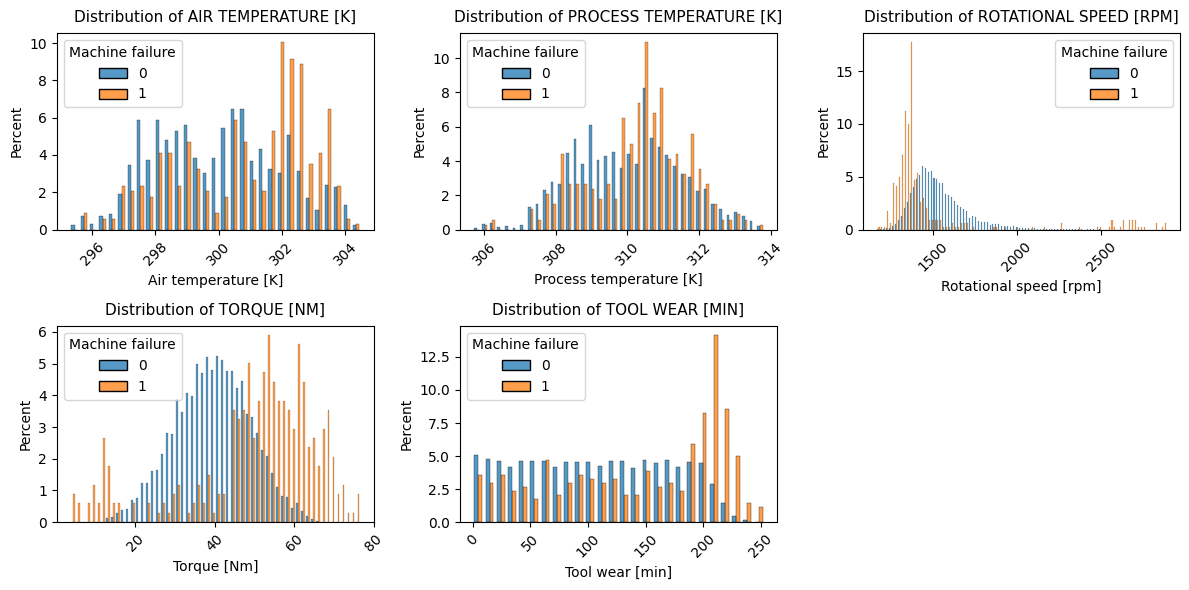

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

Numeric_Features = ['Air temperature [K]','Process temperature [K]',
                    'Rotational speed [rpm]','Torque [Nm]','Tool wear [min]']

# 1. Define grid dimensions ( 4 columns)
n_cols = 3  
n_rows = math.ceil(len(Numeric_Features) / n_cols)

# 2. Create figure canvas (adjust width and row height per subplot)
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(4 * n_cols, 3 * n_rows))

# 3. Flatten axes array
axes = axes.flatten()

# 4. Populate each subplot
for i, feature in enumerate(Numeric_Features):
    sns.histplot(
        data=df,
        x=feature,
        hue='Machine failure',
        multiple='dodge',
        stat='percent',
        common_norm=False,
        ax=axes[i],
        shrink=0.7
    )
    axes[i].set_title(f'Distribution of {feature.upper()}', fontsize=11, pad=8)
    axes[i].tick_params(axis='x', labelrotation=45)

# 5. Hide unused axes 
for j in range(len(Numeric_Features), len(axes)):
    fig.delaxes(axes[j])

# 6. Final layout adjustments
plt.tight_layout()
plt.show()

<Axes: >

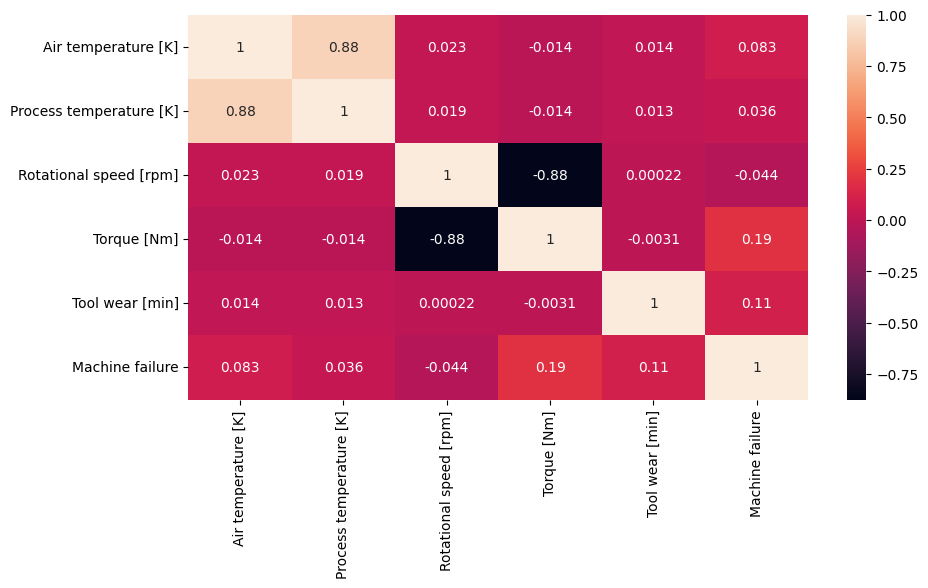

In [9]:

plt.figure(figsize = (10,5))
sns.heatmap(df.corr(numeric_only= True),annot= True)

## Checking Outliers

In [10]:
num_feature = df.select_dtypes(include= 'number')

Q1 = num_feature.quantile(0.25)
Q3 = num_feature.quantile(0.75)

IQR = Q3 - Q1
Lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

Outliers = (num_feature < Lower_bound )| (num_feature > upper_bound)
print(Outliers.sum())

Air temperature [K]          0
Process temperature [K]      0
Rotational speed [rpm]     418
Torque [Nm]                 69
Tool wear [min]              0
Machine failure            339
dtype: int64


## Skewness

 near to 0 > Centralized (0.01, 0.002)

 negative > Left Skewed (-1.56)

 poistive (toward 1) > Right Skewed (1.256)

In [11]:
num_col = df.select_dtypes(include= 'number')
num_col.skew()

Air temperature [K]        0.114274
Process temperature [K]    0.015027
Rotational speed [rpm]     1.993171
Torque [Nm]               -0.009517
Tool wear [min]            0.027292
Machine failure            5.151852
dtype: float64

In [12]:
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [13]:
df['Type'].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

##  Train-Test Split


In [14]:
from sklearn.model_selection import train_test_split 

skew_columns    = ["Rotational speed [rpm]","Torque [Nm]","Tool wear [min]"]


numerical_columns = ["Air temperature [K]","Process temperature [K]",]

Ordinal_columns = ['Type']

feature_cols    = skew_columns + numerical_columns + Ordinal_columns  


x = df[feature_cols]

y = df['Machine failure'] 

x_train,x_test,y_train,y_test = train_test_split(x, y, test_size= 0.30 , random_state= 42)


## Encoding Strategy 

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer

# 1. skew feature
skew_pipeline  = Pipeline(steps= [
    ('log_transformer',FunctionTransformer(np.log1p)),
    ('scaler',StandardScaler())
    ])
# 2. numerical feature
numerical_pipeline = Pipeline(steps= [
    ('scaler',StandardScaler())
    ])

# 2. ordinal feature
ordinal_pipeline = Pipeline(steps=[
    ('encode',OrdinalEncoder(categories= [["L","M","H"]]))
    ])


## Preprocessing using ColumnTransformer 

In [16]:
# Column Transformer 
preprocessor = ColumnTransformer(transformers=[
    ('skew_pipeline',skew_pipeline,skew_columns),
    ('numerical_pipeline',numerical_pipeline,numerical_columns),
    ('ordinal_pipeline',ordinal_pipeline,Ordinal_columns)
   ])

### import Metrics

In [17]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

## Build Model

### 1. Random Forest

In [18]:
from sklearn.ensemble import RandomForestClassifier 

rd_pipeline = Pipeline(steps = [
                                ("Preprocessor",preprocessor),
                                ("Random Forest",RandomForestClassifier(n_estimators=300,
                                                                        random_state= 42,
                                                                        class_weight='balanced'))
                                ])
# Train The Model
rd_pipeline.fit(x_train,y_train)

# Predict The Model

rd_predict = rd_pipeline.predict(x_test)

# Evaluate
print("Test Accuracy\n",accuracy_score(y_test,rd_predict))

print("\nMachine failure Recall\n",recall_score(y_test,rd_predict))

print("\nMachine failure Precision\n",precision_score(y_test,rd_predict))

print("\nMachine failure F1 score\n",f1_score(y_test,rd_predict))

print("\nROC-AUC:\n", roc_auc_score(y_test, rd_predict))

print("\nMachine failure Report\n",classification_report(y_test,rd_predict))

print("\nMatrix\n",confusion_matrix(y_test,rd_predict))

Test Accuracy
 0.9816666666666667

Machine failure Recall
 0.44086021505376344

Machine failure Precision
 0.9318181818181818

Machine failure F1 score
 0.5985401459854015

ROC-AUC:
 0.7199141116548486

Machine failure Report
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      2907
           1       0.93      0.44      0.60        93

    accuracy                           0.98      3000
   macro avg       0.96      0.72      0.79      3000
weighted avg       0.98      0.98      0.98      3000


Matrix
 [[2904    3]
 [  52   41]]


### 2. XGBoost Classifier

In [20]:
from xgboost import XGBClassifier

xg_pipeline = Pipeline(steps=[("Preprocessor",preprocessor),
                              ("Xgboost",XGBClassifier(n_estimators=200, learning_rate=0.2,max_depth=5,random_state=42
                             ))])

# Train The Model
xg_pipeline.fit(x_train,y_train)

# Predict The Model
xg_predict = xg_pipeline.predict(x_test)

# Evaluate

print("Test Accuracy\n",accuracy_score(y_test,xg_predict))

print("\nMachine failure Recall\n",recall_score(y_test,xg_predict))

print("\nMachine failure Precision\n",precision_score(y_test,xg_predict))

print("\nMachine failure F1 score\n",f1_score(y_test,xg_predict))

print("\nROC-AUC:\n", roc_auc_score(y_test, xg_predict))

print("\nMachine failure Report\n",classification_report(y_test,xg_predict))

print("\nMatrix\n",confusion_matrix(y_test,xg_predict))

Test Accuracy
 0.9843333333333333

Machine failure Recall
 0.6559139784946236

Machine failure Precision
 0.8026315789473685

Machine failure F1 score
 0.7218934911242604

ROC-AUC:
 0.8253770098871466

Machine failure Report
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      2907
           1       0.80      0.66      0.72        93

    accuracy                           0.98      3000
   macro avg       0.90      0.83      0.86      3000
weighted avg       0.98      0.98      0.98      3000


Matrix
 [[2892   15]
 [  32   61]]


## Random Forest vs XGBoost – Machine Failure Prediction

| Metric | Random Forest | **XGBoost** |
|---|---:|---:|
| Test Accuracy | 98.17% | **98.43%** |
| Failure Precision | **93.18%** | 80.26% |
| **Failure Recall** | 44.09% | **65.59%** |
| **Failure F1-score** | 59.85% | **72.19%** |
| ROC-AUC | 71.99% | 82.53% |

### Key Result

**XGBoost was selected as the final model** because it detects significantly more actual machine failures while maintaining high overall accuracy.

- **61 vs 41** actual failures detected
- **32 vs 52** false negatives
- Recall improved from **44.09% → 65.59%**
- F1-score improved from **59.85% → 72.19%**
- Accuracy improved from **98.17% → 98.43%**
- ROC-AUC  improved from **71.99% → 82.53%**

### Business Impact

Although Random Forest has higher precision (**93.18%**), it misses **52 actual failures**. XGBoost reduces missed failures to **32**, which is more valuable in predictive maintenance where undetected failures can lead to unexpected downtime.

> **Takeaway:** XGBoost improved failure detection by **21.5 percentage points in recall** and reduced missed failures by **38.5%**, while maintaining **98.43% accuracy**.